# Performance Assessment

<img src="./img/5_performance_assessment.png" width="500px"><br><br>

If we want to know how good an estimator performs, we can calculate some performance metrics.

Here we will dig a little deeper into

- Accuracy
- Confusion matrices

and meet new metrices

- Precision
- Recall and
- F1 score



### Performance Assessment for kNN based Classification

Starting point: We create a classification model using kNN (example from last lecture).

In [1]:
# Load required libraries (basics)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

In [2]:
# we set k to 7
n_neighbors = 7

# import some data to play with
iris = load_iris()

# we only take the first two features. We could avoid this ugly
# slicing by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# split data (67% training, 33% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [3]:
# we create an instance of kNN Classifier and fit the data.
knn_clf = KNeighborsClassifier(n_neighbors, weights='distance')
knn_clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Confusion matrix
A Confusion matrix is a figure or a table that is used to describe the performance of a classifier. It is usually extracted from a test dataset for which the ground truth is known. We compare each class with every other class and see how many samples are misclassified. During the construction of this table, we actually come across several key metrics that are very important in the field of machine learning.

Let's consider a binary classification case where the output is either 0 or 1:
* **True positives:** These are the samples for which we predicted 1 as the output and the ground truth is 1 too.
* **True negatives:** These are the samples for which we predicted 0 as the output and the ground truth is 0 too.
* **False positives:** These are the samples for which we predicted 1 as the output but the ground truth is 0. This is also known as a Type I error.
* **False negatives:** These are the samples for which we predicted 0 as the output but the ground truth is 1. This is also known as a Type II error.

Depending on the problem at hand, we may have to optimize our algorithm to reduce the false positive or the false negative rate. For example, in a biometric identification system, it is very important to avoid false positives, because the wrong people might get access to sensitive information. Let's see how to create a confusion matrix.

In [4]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Define sample labels
print(f"True labels:\n{y_test}")
y_pred = knn_clf.predict(X_test)
print(f"Predicted labels:\n{y_pred}")

True labels:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 2 2 1 2]
Predicted labels:
[1 0 2 1 1 0 1 1 1 1 2 0 0 0 0 2 2 1 1 2 0 1 0 2 2 1 1 2 0 0 0 0 2 0 0 1 2
 0 0 0 1 2 2 0 0 1 2 2 2 2]


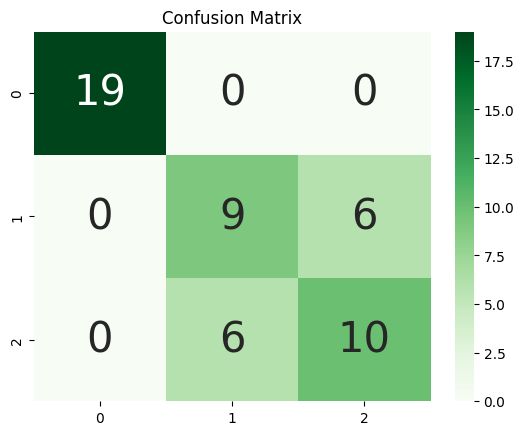

Accuracy:
 Train: 96.00 %
 Test:  76.00 %


In [5]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, knn_clf.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')


#### Quality measures and cross-validation for a classification model

Measures to evaluate the quality of a machine learning technique (precision, recall, accuracy and F1 are the most important ones):<br><br>

<img src="./img/5_performance_metric.png" width="1000px">

In [6]:
# Classification report (as created by sklearn)
print('\n', classification_report(y_test, y_pred, target_names=iris.target_names))


               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.60      0.60      0.60        15
   virginica       0.62      0.62      0.62        16

    accuracy                           0.76        50
   macro avg       0.74      0.74      0.74        50
weighted avg       0.76      0.76      0.76        50



### Cross validation

<img src="./img/5_cross_validation.png" width="700px"><br><br>

`Cross validation` splits the __training data__ into segments (___k-folds___) and trains the model iteratively.

Each iteration is then tested against the test set. The errors are leveled out.

This allows for higher model quality and generalization capabilities.

Calculating quality measures through cross-validation:

In [7]:
from sklearn import model_selection

# this defines the cross-validation strategy (cv parameter)
num_folds = 3
# 3 means: 3 folds (sets) for cross-validation

# Scoring functions of sklearn (original data: X and y!)
accuracy_values = model_selection.cross_val_score(knn_clf, X, y, scoring='accuracy', cv=num_folds)
print(f"Accuracy:  {accuracy_values.mean():.2f}% -> {accuracy_values}")

precision_values = model_selection.cross_val_score(knn_clf, X, y, scoring='precision_weighted', cv=num_folds)
print(f"Precision: {precision_values.mean():.2f}% -> {precision_values}")

recall_values = model_selection.cross_val_score(knn_clf, X, y, scoring='recall_weighted', cv=num_folds)
print(f"Recall:    {recall_values.mean():.2f}% -> {recall_values}")

f1_values = model_selection.cross_val_score(knn_clf, X, y, scoring='f1_weighted', cv=num_folds)
print(f"F1:        {f1_values.mean():.2f}  -> {f1_values}")

Accuracy:  0.79% -> [0.76 0.82 0.78]
Precision: 0.81% -> [0.76738462 0.82415385 0.82673077]
Recall:    0.79% -> [0.76 0.82 0.78]
F1:        0.78  -> [0.75733333 0.81798695 0.76342326]


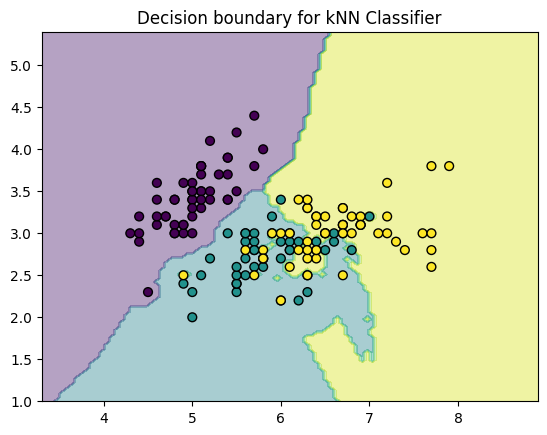

In [8]:
# Draw decision boundaries
DecisionBoundaryDisplay.from_estimator(knn_clf, X, alpha=0.4, response_method="predict")
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")
plt.title("Decision boundary for kNN Classifier")
plt.show()

Compared to our single fold `kNN` classifier, the `cross validation` offers better overall performance:<br><br>

<table>
    <tr>
        <td style="border: none">&nbsp;</td>
        <td style="text-align:center">single fold kNN</td>
        <td style="text-align:center">cross validation kNN</td>
    <tr>
    <tr>
        <td>Accuracy</td>
        <td style="text-align:center">0.76</td>
        <td style="text-align:center">0.79</td>
    <tr>
    <tr>
        <td>Precision</td>
        <td style="text-align:center">0.74</td>
        <td style="text-align:center">0.81</td>
    <tr>
    <tr>
        <td>Recall</td>
        <td style="text-align:center">0.74</td>
        <td style="text-align:center">0.79</td>
    <tr>
    <tr>
        <td>F1</td>
        <td style="text-align:center">0.74</td>
        <td style="text-align:center">0.78</td>
    <tr>
</table>

<span style="font-size:70%">Cross validation provides higher overall performance measures.</span>